In [1]:
# Add src to path to allow importing net_epistemology without installing the package
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))


# Basic Testing (Vectorized)

In this notebook we test that the vectorized files work well and produce similar results to the original model.

## Setup

In [2]:
from net_epistemology.utils.imports import *
from net_epistemology.core.vectorized_model import VectorizedModel
import matplotlib.pyplot as plt

## Try with Bayes Agent (Vectorized)

In [3]:
n_agents = 100
my_network = nx.gnp_random_graph(n_agents, p=0.2, directed=True)

In [4]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='bayes')
my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
print('conclusion core', my_model.conclusion_core)

df_bayes = pd.DataFrame(my_model.credences_history).T
df_bayes.head(3)

100%|██████████| 10000/10000 [00:01<00:00, 6424.06it/s]


steps:  10000
conclusion:  1.0
conclusion core 1.0


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.778443,0.153183,0.836172,0.104748,0.976674,0.115350,0.418731,0.367012,0.534928,0.334613,...,0.478404,0.098457,0.690919,0.032203,0.788262,0.015187,0.477424,0.401057,0.011100,0.888289
1,0.775671,0.160589,0.833969,0.111694,0.976121,0.110542,0.422630,0.385787,0.538906,0.336397,...,0.486394,0.102065,0.689208,0.034792,0.788262,0.016302,0.485413,0.408767,0.011012,0.887492
2,0.779819,0.157380,0.840509,0.108559,0.976121,0.109758,0.416785,0.383893,0.532937,0.343577,...,0.470425,0.103541,0.684044,0.033995,0.788262,0.016823,0.473434,0.399137,0.011547,0.889080


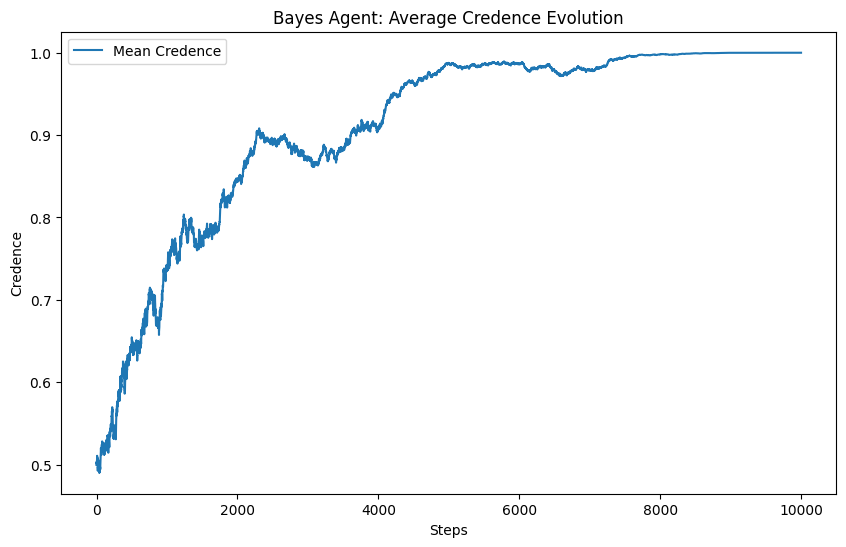

In [5]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()

## Try with Beta Agent (Vectorized)

In [6]:
n_agents = 100
my_network = nx.gnp_random_graph(n_agents, p=0.2, directed=True)

In [7]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='beta')

my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)

# agent_histories in VectorizedModel is a list of lists of numpy arrays
df = pd.DataFrame(my_model.credences_history).T # Transpose because history[agent] is list of steps
df.head(3)

100%|██████████| 10000/10000 [00:02<00:00, 4138.20it/s]


steps:  10000
conclusion:  0.8


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,"[0.383560074523888, 0.05310168368721058]","[0.0761732440624584, 0.43107689457494447]","[0.823325947852423, 0.5887391179590802]","[0.4913489787826573, 0.22790596863276097]","[0.03587976305099028, 0.7397285194589065]","[0.9974219229708126, 0.46044748660898227]","[0.556305713455173, 0.8555733914806174]","[0.354770989019011, 0.49159985920121196]","[0.660026273287533, 0.2060982209376595]","[0.41057010392248305, 4.271492691944638e-05]",...,"[0.9971052527511751, 0.006479103547041453]","[0.7655289311099595, 0.6024665835679955]","[0.47251827945290487, 0.9604819684479435]","[0.014754286453320746, 0.23519820727969362]","[0.05096533116088772, 0.557625774924427]","[0.00045778445049105465, 0.4043307588899663]","[0.9151639127758698, 0.4565217492991353]","[0.3205218229845795, 0.47827179535989983]","[0.2919065209514612, 0.8355341070448105]","[0.22012641364773014, 8.420630560170516e-07]"
1,"[0.4397743576435924, 0.6254112121569868]","[0.5328341429037312, 0.5561353545738091]","[0.4869045757887471, 0.49492004838758014]","[0.4099493833484009, 0.5781881074943978]","[0.4166214844043526, 0.4732698065595154]","[0.520063255756094, 0.5152619573021945]","[0.5545885573493458, 0.4434233669064165]","[0.5151348448686054, 0.5195679778579059]","[0.5466621418156082, 0.5730078197258288]","[0.5355995329298007, 0.5034149433620384]",...,"[0.4322324713429076, 0.5376406388237995]","[0.44383365081253406, 0.43836121822588425]","[0.5803988063328565, 0.5957596180270995]","[0.5837013662758364, 0.3194330219842361]","[0.47709350981165694, 0.4860076351387672]","[0.5447425263508873, 0.5121204749604445]","[0.5821669205588065, 0.5106314150447631]","[0.36942270486852674, 0.5693843774292088]","[0.43935129444416704, 0.47310531356091473]","[0.47784893051408145, 0.3237499866988013]"
2,"[0.5086778289967309, 0.5012421661611947]","[0.4582020458118072, 0.4842530071012462]","[0.47550218142784795, 0.4658925954363253]","[0.4563519810309149, 0.5017738729445371]","[0.4481591765465957, 0.4674804730654713]","[0.45163908736796043, 0.47947686589531857]","[0.517895524555237, 0.4440267094773083]","[0.5152670708529888, 0.490610402500564]","[0.5376441682070116, 0.5246434299805622]","[0.4501027116532234, 0.5498743847032324]",...,"[0.5146528431055423, 0.5176398828336062]","[0.4900732172774042, 0.44147596193002436]","[0.5509767648285276, 0.49521216700085]","[0.6017896551020555, 0.4166292892537628]","[0.5190084627762351, 0.5585188244217134]","[0.5420758548655765, 0.5098835771820213]","[0.49740982818198604, 0.5321684079114166]","[0.4525928171893664, 0.5138302678156917]","[0.523715444761032, 0.4401962734674477]","[0.4434231532847689, 0.4953702876782177]"


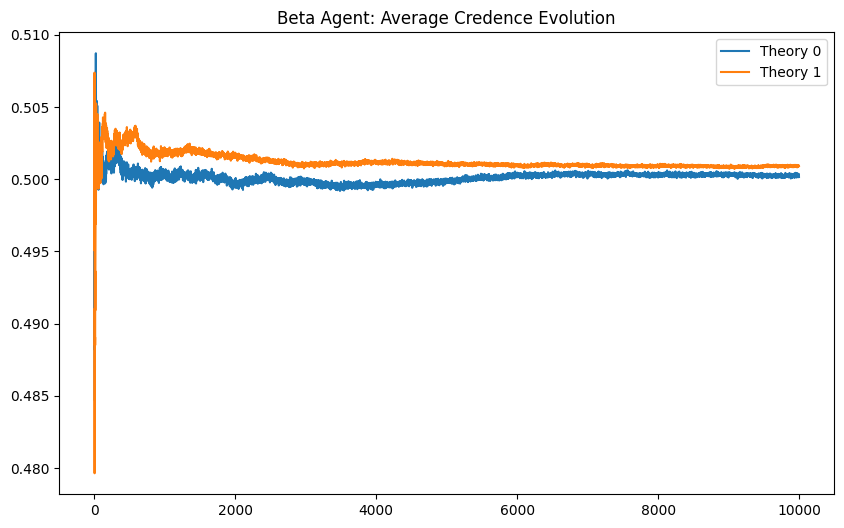

In [8]:
# Extract the first coordinate (x) for each pair and calculate column-wise mean
# In vectorized model, credences are stored as arrays [c0, c1].
x_means = df.map(lambda pair: pair[0]).mean(axis=1)
y_means = df.map(lambda pair: pair[1]).mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(x_means, label='Theory 0')
plt.plot(y_means, label='Theory 1')
plt.title('Beta Agent: Average Credence Evolution')
plt.legend()
plt.show()

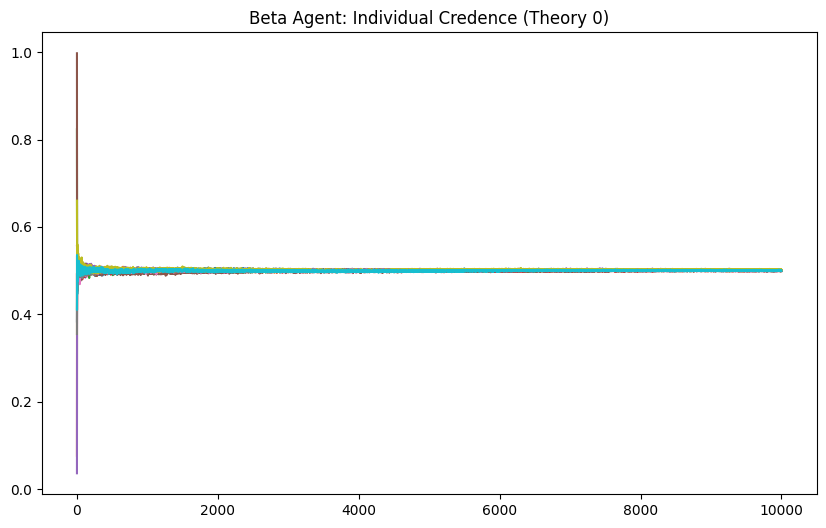

In [9]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row (agent)
plt.figure(figsize=(10, 6))
# Plot a subset of agents to avoid clutter if N is large
for agent_idx in range(min(10, x_values.shape[1])):
    plt.plot(x_values[agent_idx], label=f'Agent {agent_idx}')
plt.title('Beta Agent: Individual Credence (Theory 0)')
plt.show()